GitHub Repository:

## Task 1 - Identifying the Prediction Target

We must specify exactly what we are trying to predict before we can start any data preparation or modeling. Every following choice involving feature engineering, encoding, scaling, and evaluation depends on an in-depth understanding of the prediction target, making this the most important step in any machine learning process.

We are using a dataset from a Portuguese bank that conducted direct telemarketing campaigns. Convincing customers to sign up for a term deposit, a short-term financial product, was the goal of those ads. Therefore, our job is to predict whether or not a client will subscribe based on the facts provided at the moment of contact.

The dataset columns are examined to determine which variable best captures this result, confirm its data type and class distribution, and provide an explanation for why other variables that would appear to be valid targets on surface level shouldn't be.

In [1]:
import pandas as pd

df = pd.read_csv('bank-additional.csv', sep=';')
print(df.columns.tolist())
print(df['y'].value_counts())
print(df['y'].dtype)

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
y
no     3668
yes     451
Name: count, dtype: int64
str


We load the dataset and inspect the target column `y`, printing all column names, the class distribution, and the data type to confirm it is a binary categorical variable.

### Target Variable: 'y'
The column 'y' is the prediction target which indicates if the client subscribed to a term deposit or not, ('yes) or ('no). This is related to the advertising goal of the campaign, which is to identify clients who are likely to convert.

## Task Ordering

Determining the proper order in which tasks should be completed is important before beginning any data preparation processes. Even if every stage is performed out perfectly, incorrect sequencing can result in biased evaluation, data leakage, or inaccurate models.

### Chosen Pipeline Order

**1. Identifying the Prediction Target**
Since every decision that comes next depends on understanding what we are trying to predict, this must come first. We have no way to make conclusions about leakage, encoding, or feature relevance without knowing the target.

**2. Data Loading and Exploration**
Before making any changes, we look over the raw data. This provides with an accurate representation of the dataset, including its distribution, missing values, structure, and possible problems, without any modifications that may hide the data's initial state.

**3. Data Splitting**
Prior to any transformation that learns parameters from data, the dataset must be divided into training, validation, and test sets. The most important ordering choice in the pipeline is this one. Imputation, encoding, scaling, feature selection, and resampling are the next processes that must be fitted using only the training data. The only way to ensure this is to split first.

**4. Managing Missing Values**
Imputation is performed after splitting because imputation parameters, such as using the median to fill messing values, must be computed from the training set only. If we performed imputation before splitting, the median would be computed using test set values, leaking information into the training process.

**5. Encoding Categorical Variables**
Since the encoder must only be fitted on clean training data, encoding happens after splitting and handling missing values. The encoder would be exposed to the categories and distributions found in the test set if it were fitted to the entire dataset.

**6. Feature Scaling**
Scaling comes after encoding because we need all features to be numerical before we can compute means and standard deviations. The scaler is fitted on the training set only since applying it before splitting would leak test set statistics into the transformation.

**7. Feature Selection**
Before we can calculate means and standard deviations, every feature must be numerical, therefore scaling comes after encoding. Since the scaler is only appropriate for the training set, using it before splitting would introduce test set statistics into the transformation.

**8. Addressing Class Imbalance**
Resampling is the last preprocessing step before training since it modifies the training set distribution. It must be applied after all other transformations so that SMOTE operates on the final, clean, encoded, and scaled feature space. Applying it before splitting would contaminate the test set with synthetic samples.

**9. Training a Logistic Regression Model**
After the pipeline has been completely built and verified, training is always the final step. The revised training set is used to fit the model, and the untouched validation set is used for evaluation.

-----------

### What Could Go Wrong With Incorrect Ordering

Preprocessing the data before splitting it causes data leakage and produces evaluation results that are too positive. Information from the test set affects the transformations when scaling, encoding, imputation, feature selection, or resampling (like SMOTE) are applied to the entire dataset. This means that during training, the model "sees" test data indirectly through shared statistics, chosen features, or synthetic samples that are generated from it. As a result, performance measurements no longer accurately represent real-world behavior, and the model seems to generalize better than it actually does.

## Task 2 - Data Loading and Exploration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank-additional.csv', sep=';')

print("Dataset Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n Data Types")
print(df.dtypes)

print("\nData Descriptions")
print(df.describe())

Dataset Shape
Rows: 4119, Columns: 21

 Data Types
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Data Descriptions
               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   


The dataset has 4,119 rows and 21 columns: 10 are numerical and 11 are categorical, including the target 'y'.

In [3]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [4]:
print("== Target Variable Distribution ==")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

== Target Variable Distribution ==
y
no     3668
yes     451
Name: count, dtype: int64
y
no     89.05%
yes    10.95%
Name: proportion, dtype: str


**Target Imbalance:** 89.1% say 'no' and 10.9% say 'yes'. This is certainly a significant imbalance that will need to be addressed on further steps.

In [5]:
print("Explicit Missing Values (NaN)")
print(df.isnull().sum())

print("Implicit Missing Values ('unknown')")
for col in categorical_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"{col}: {n} unknowns ({n/len(df)*100:.2f}%)")

Explicit Missing Values (NaN)
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Implicit Missing Values ('unknown')
job: 39 unknowns (0.95%)
marital: 11 unknowns (0.27%)
education: 167 unknowns (4.05%)
default: 803 unknowns (19.50%)
housing: 105 unknowns (2.55%)
loan: 105 unknowns (2.55%)


**NaN Values:** No explicit NaN values are present, but many categorical columns contain "unknown" entries which propably act as implicit missing values. These are: `job`, `marital`, `education`, `default`, `housing`, and `loan`

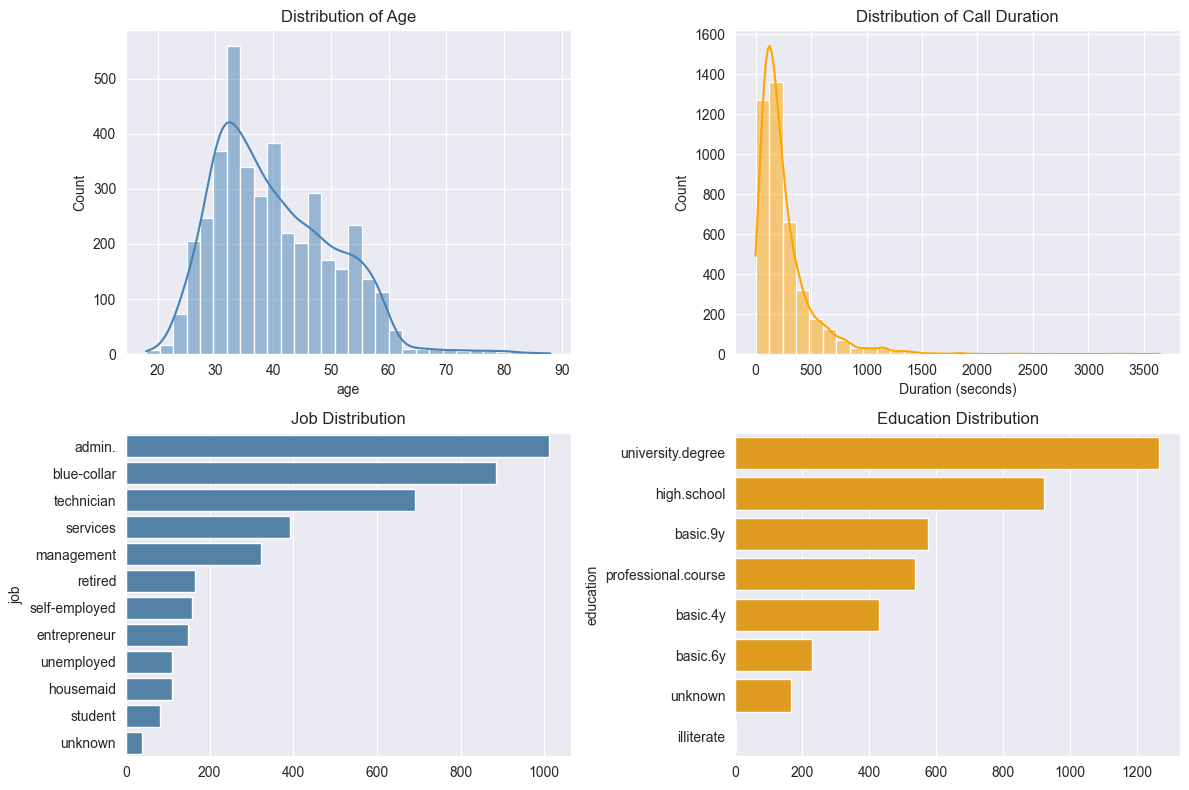

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Numerical: age
sns.histplot(df['age'], bins=30, ax=axes[0,0], color='steelblue', kde=True)
axes[0,0].set_title('Distribution of Age')

# Numerical: duration
sns.histplot(df['duration'], bins=30, ax=axes[0,1], color='orange', kde=True)
axes[0,1].set_title('Distribution of Call Duration')
axes[0,1].set_xlabel('Duration (seconds)')

# Categorical: job
job_counts = df['job'].value_counts()
sns.barplot(x=job_counts.values, y=job_counts.index, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Job Distribution')

# Categorical: education
edu_counts = df['education'].value_counts()
sns.barplot(x=edu_counts.values, y=edu_counts.index, ax=axes[1,1], color='orange')
axes[1,1].set_title('Education Distribution')

plt.tight_layout()
plt.show()

**`duration`** needs special attention because it represents the call duration in seconds, which is only known after the call ends. This means it is not available at true prediction time and creates risk of data leakage if kept as a feature.
Also `duration` as we can see is heavily right-skewed. Most calls short and few are very long.
**`age`** is also right-skewed with most clients between 25-60.
(These graphs were made using the help of AI)

## Task 3 - Data Splitting

In [7]:
from sklearn.model_selection import train_test_split

#Separate features and target
X = df.drop(columns=['y'])
y = df['y']

#First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: temp → 50% val, 50% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("== Split Sizes ==")
print(f"Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.1f}%)")

== Split Sizes ==
Training set: 3295 rows (80.0%)
Validation set: 412 rows (10.0%)
Test set:       412 rows (10.0%)


### Annotations
**1. Proportions** I used an 80/10/10 (train/val/test), and here is why:
- The training set needs to be large enough for the model to learn but not memorize, so learn reliably.
- Validation (10%) is for tuning decisions during the pipeline
- Test (10%) is held out entirely until the final evaluation.

**2. Why stratify?**
I used stratification to make sure each split has the same class distribution as the original set. In this particular case, since there is only around 11% of positive example, a random split could produce a validation or test set with very to no 'yes' cases. This would then make the evaluation unreliable.

**3. Why split before any preprocessing?**
Only training data should be accessed by any transformation that learns parameters from data, such as fitting encoders, fitting scalers, or computing methods for imputation. By splitting first, data leakage is avoided and validation and test sets are kept totally hidden.

**4. Example of incorrect ordering:**
If I scaled the entire dataset before splitting, the scaler would compute the mean and standard deviation using the test set values. The model would then be evaluated on data it has indirectly already seen. This would produce optimistic biased metrics.



In [8]:
print("== Explicit Missing Values (NaN) ==")
print(X_train.isnull().sum())

== Explicit Missing Values (NaN) ==
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64


**Explicit Missing Values:**
No NaN values are present in the raw dataset.

In [9]:
print("== Implicit Missing Values in Training Set ==")
for col in X_train.select_dtypes(include=['object', 'str']).columns:
    n = (X_train[col] == 'unknown').sum()
    if n > 0:
        pct = n / len(X_train) * 100
        print(f"{col}: {n} unknowns ({pct:.2f}%)")

== Implicit Missing Values in Training Set ==
job: 28 unknowns (0.85%)
marital: 7 unknowns (0.21%)
education: 129 unknowns (3.92%)
default: 663 unknowns (20.12%)
housing: 78 unknowns (2.37%)
loan: 78 unknowns (2.37%)


**Implicit Missing Values:**
- As mentioned above, there are several categorical columns which contain 'unknown' entries. These are: `job`, `marital`, `education`, `default`, `housing`, `loan`. These should be treated as a separate category rather than imputing, because the fact that a client decided not to give certain information may be predictive of behavior.


In [10]:
print("=== Value counts for pdays ===")
print(X_train['pdays'].value_counts().head(10))

=== Value counts for pdays ===
pdays
999    3160
3        44
6        38
4        13
7         8
10        6
12        5
2         3
18        2
0         2
Name: count, dtype: int64


**Sentinel Value**
- `pdays = 999` is a sentinel value. This means the client was never previously contacted. It is not a real number of days, so it can be replaced with NaN and impute using the median of the training set. And the median is used rather than mean because the distribution is skewed.

In [11]:
# Replace 999 with NaN to make the missingness explicit, then its impute with median
import numpy as np

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train['pdays'] = X_train['pdays'].replace(999, np.nan)
X_val['pdays'] = X_val['pdays'].replace(999, np.nan)
X_test['pdays'] = X_test['pdays'].replace(999, np.nan)

# Fit median on training set only
pdays_median = X_train['pdays'].median()
print(f"pdays median (training set): {pdays_median}")

X_train['pdays'] = X_train['pdays'].fillna(pdays_median)
X_val['pdays'] = X_val['pdays'].fillna(pdays_median)
X_test['pdays'] = X_test['pdays'].fillna(pdays_median)

pdays median (training set): 6.0


**Why fit imputation on training only?**

Calculating the median on the complete dataset would result in the training set mistakenly including information from the validation and test sets, leading to a type of data leakage. Before applying any imputation parameters to val/test, they must all be learned completely from the training set.

In [12]:
unknown_cols = []
for col in X_train.select_dtypes(include=['object', 'str']).columns:
    n = (X_train[col] == 'unknown').sum()
    if n > 0:
        unknown_cols.append(col)

print("Columns with 'unknown' kept as separate category:", unknown_cols)


Columns with 'unknown' kept as separate category: ['job', 'marital', 'education', 'default', 'housing', 'loan']


**Handling `'unknown'` in Categorical Columns**

Instead of imputing the most frequent value to categorical columns with `'unknown'` entries, I decided to keep `'unknown'` as a separate category. This is for two reasons:
1. A predictive signal may be carried by missingness.
A client with an average job or no default is not the same as one who decided not to reveal their credit default status or type of employment. These clients may act consistently differently from those who responded, therefore the act of keeping information is informative. This indicator would be completely destroyed if the mode were substituted for `'unknown'`.
2. The missing-at-random assumption cannot be verified.
Only when the data is missing completely at random (MCAR) is imputation using the mode safe. Since there isn't much evidence to support that, it is more wise and accurate to classify `'unknown'` as a separate category.

By doing so, we are explicitly telling the model that "unknown" is a meaningful state that is different from any known category, which is a **modeling decision** rather than simply a data cleaning step.

## Task 5: Encoding Categorical Variables

In [13]:
# Nominal: no meaningful order
nominal_cols = ['job', 'marital', 'contact', 'poutcome', 'default', 'housing', 'loan']

# Ordinal: meaningful order exists
ordinal_cols = ['education', 'month', 'day_of_week']

print("Nominal columns:", nominal_cols)
print("Ordinal columns:", ordinal_cols)

Nominal columns: ['job', 'marital', 'contact', 'poutcome', 'default', 'housing', 'loan']
Ordinal columns: ['education', 'month', 'day_of_week']


**Nominal variables** (`job`, `marital`, `contact`, `poutcome`, `default`, `housing`, `loan`) have no natural order. For example, a job  such as "admin" and "technician" can't be meaningfully ranked. In this case I use One-Hot Encoding (OHE) to generate a binary column for every category. For logistic regression, this is the best option because:
- False ordering between categories is not imposed.
- It allows each category's independent coefficient to be learned by the model.




In [14]:
education_order = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2,
    'basic.9y': 3, 'high.school': 4, 'professional.course': 5,
    'university.degree': 6, 'unknown': 7
}
month_order = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
day_order = {'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5}

for dataset in [X_train, X_val, X_test]:
    dataset['education'] = dataset['education'].map(education_order)
    dataset['month'] = dataset['month'].map(month_order)
    dataset['day_of_week'] = dataset['day_of_week'].map(day_order)

print("Ordinal encoding done.")
print(X_train[['education', 'month', 'day_of_week']].head())

Ordinal encoding done.
      education  month  day_of_week
2782          6      5            2
2547          4      5            2
2994          3      5            3
3626          5      8            4
2462          4      5            3


For ordinal variables we manually assign integers that reflect the true order:
- `education`: Mapped from 0 (illiterate) to 6 (university degree), with unknown assigned 7 as a separate value
- `month`: Mapped 1–12 following chronological order
- `day_of_week`: Mapped 1–5 from Monday to Friday We apply the same mapping to train, validation, and test sets. No fitting is required here since the mappings are defined manually based on domain knowledge, not learned from the data.

In [15]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training only
ohe.fit(X_train[nominal_cols])

ohe_feature_names = ohe.get_feature_names_out(nominal_cols)

X_train_ohe = pd.DataFrame(ohe.transform(X_train[nominal_cols]),
                            columns=ohe_feature_names, index=X_train.index)
X_val_ohe = pd.DataFrame(ohe.transform(X_val[nominal_cols]),
                          columns=ohe_feature_names, index=X_val.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test[nominal_cols]),
                           columns=ohe_feature_names, index=X_test.index)

# Drop original nominal columns and attach encoded ones
X_train = X_train.drop(columns=nominal_cols).join(X_train_ohe)
X_val = X_val.drop(columns=nominal_cols).join(X_val_ohe)
X_test = X_test.drop(columns=nominal_cols).join(X_test_ohe)

print(f"Shape after encoding: {X_train.shape}")
print("Remaining string columns:", X_train.select_dtypes(include=['object', 'str']).columns.tolist())

Shape after encoding: (3295, 43)
Remaining string columns: []


*Code assistance generated with Claude (Anthropic), using the prompt shown below (accessed on March 1, 2026). "Generate scikit-learn code to one-hot encode only the nominal categorical variables (job, marital, contact, poutcome, default, housing, loan) using OneHotEncoder fitted on the training set only and applied to validation and test sets to avoid data leakage. Put together the encoded columns back with the remaining features and print the shape and any remaining string columns after encoding."*

For nominal variables we apply **One-Hot Encoding (OHE)**, which creates a separate binary column for each category. This is the correct choice for Logistic Regression because:

- It does not impose any false ordering between unordered categories
- It allows the model to learn an independent coefficient for each category
- Using raw label encoding on nominal variables would mislead the model into thinking some categories are "greater than" others

**Important:** The encoder is fitted on the training set only, then applied to validation and test. This prevents the encoder from learning categories that only exist in the test set. We use `handle_unknown='ignore'` to safely handle any unseen categories in val/test by encoding them as all zeros.

After encoding, the dataset expands from the original nominal columns to multiple binary columns (one per category) increasing dimensionality but ensuring correct representation.

## Task 6 - Feature Scaling

In [16]:
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                  'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                  'euribor3m', 'nr.employed']

print("Numerical columns to scale:", numerical_cols)
print("\nBefore scaling:")
X_train[numerical_cols].describe().round(2)

Numerical columns to scale: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Before scaling:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00
mean,40.18,256.21,2.51,5.99,0.20,0.07,93.57,-40.40,3.61,5165.58
std,10.37,256.89,2.54,0.77,0.56,1.57,0.58,4.63,1.74,74.29
min,18.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.64,4963.60
25%,32.00,102.00,1.00,6.00,0.00,-1.80,93.08,-42.70,1.33,5099.10
50%,38.00,180.00,2.00,6.00,0.00,1.10,93.44,-41.80,4.86,5191.00
75%,47.00,315.00,3.00,6.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,86.00,3643.00,35.00,19.00,6.00,1.40,94.77,-26.90,5.04,5228.10


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training set only
scaler.fit(X_train[numerical_cols])

# Transform all splits
X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("After scaling:")
X_train[numerical_cols].describe().round(2)

After scaling:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00,3295.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.14,-1.00,-0.60,-7.77,-0.36,-2.21,-2.36,-2.24,-1.71,-2.72
25%,-0.79,-0.60,-0.60,0.01,-0.36,-1.19,-0.86,-0.50,-1.31,-0.90
50%,-0.21,-0.30,-0.20,0.01,-0.36,0.66,-0.22,-0.30,0.72,0.34
75%,0.66,0.23,0.19,0.01,-0.36,0.85,0.72,0.86,0.78,0.84
max,4.42,13.19,12.79,16.87,10.37,0.85,2.05,2.92,0.83,0.84


**Why StandardScaler?**
Because gradient descent is used to optimize logistic regression, which works best when features are on the same scale, we use standardization (zero mean, unit variance). By making sure every variable contributes more equally, standardization ensures faster and more stable convergence.

Since features like `duration` and `campaign` are right-skewed and contain outliers, standardization is less affected by extreme values than min-max normalization. As a result, StandardScaler offers a more reliable and appropriate scaling technique for this dataset.

**Impact on model coefficients:**
Coefficients become directly comparable after standardization; a higher coefficient really indicates that a feature has a greater impact on the prediction rather than just having a larger raw scale.

**Impact on regularization:**
Coefficients are subject to a regularization penalty in logistic regression. Without scaling, the penalty could distort the model by unfairly shrinking the coefficients of large-scale features more than small-scale ones. Scaling guarantees that regularization is applied equally to every feature.

**Why fit the scaler on training only?**
The scaler computes the mean and standard deviation from the data it is fitted on. If fitted on the full dataset, it would incorporate test set statistics into the transformation. A direct form of data leakage. We fit on training and apply the same parameters to val and test.


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Label encoding: {'no': np.int64(0), 'yes': np.int64(1)}


*Code assistance generated with Claude (Anthropic), using the prompt shown below (accessed on March 1, 2026). "How do I encode the target variable y from text labels ('yes'/'no') into numbers using LabelEncoder, fitting on the training set only and applying the same encoder to validation and test sets to avoid data leakage?"*

`LabelEncoder` converts the target variable from text labels into numerical values, mapping 'no' to 0 and 'yes' to 1. This is necessary because Logistic Regression can only operate on numerical inputs, not strings. The np.int64 type simply indicates that the values are stored as 64-bit integers, which is just NumPy’s internal numeric format.

In [19]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

low_variance_cols = X_train.columns[~selector.get_support()].tolist()
print("Low variance columns:", low_variance_cols)

Low variance columns: ['job_unknown', 'marital_unknown', 'default_yes']


**Low variance features:**
The variance threshold used was of 0.01. This is used so that any feature with variance below this is essentially constant across samples and carries no useful information for the model.

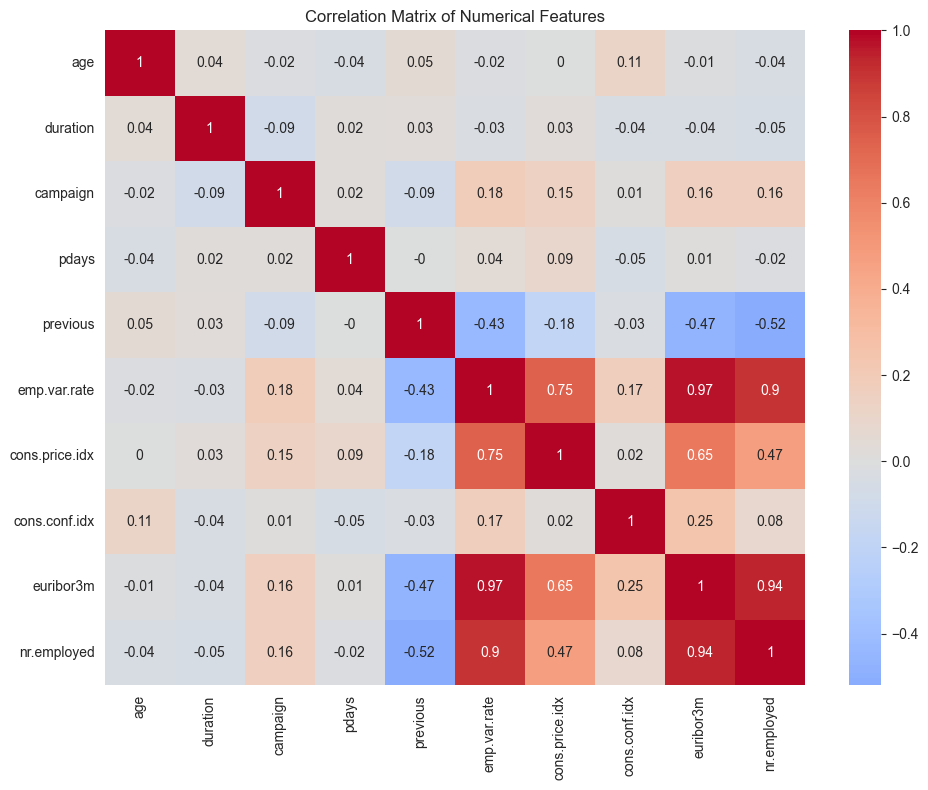

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                  'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                  'euribor3m', 'nr.employed']

corr_matrix = X_train[numerical_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

This is a correlation matrix. It shows how strongly pairs of numerical features are related to each other. Here is what it shows:

Value close to 1  → strong positive correlation — both variables increase together

Value close to -1  → strong negative correlation — one increases as the other decreases

Value close to 0  → little to no relationship

- `emp.var.rate` and `euribor3m` → 0.97  extremely high correlation
- `emp.var.rate` and `nr.employed` → 0.97  extremely high correlation
- `euribor3m` and `nr.employed` → 0.94  extremely high correlation
- `cons.price.idx `and `euribor3m `→ 0.65 moderately correlated

This makes sense because all four are macroeconomic indicators. They all reflect the same underlying economic conditions, so they move together.
With the threshold of 0.85, the correlated features cell will drop the redundant ones.

In [22]:
# Remove features with correlation > 0.85
threshold = 0.85
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col = corr_matrix.columns[j]
            to_drop.add(col)
            print(f"High correlation ({corr_matrix.iloc[i,j]:.2f}): "
                  f"{corr_matrix.columns[i]} vs {col}")

print(f"\nColumns to drop due to high correlation: {to_drop}")

X_train = X_train.drop(columns=to_drop)
X_val = X_val.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print(f"Shape after removing correlated features: {X_train.shape}")

High correlation (0.97): emp.var.rate vs euribor3m
High correlation (0.90): emp.var.rate vs nr.employed
High correlation (0.94): euribor3m vs nr.employed

Columns to drop due to high correlation: {'euribor3m', 'nr.employed'}
Shape after removing correlated features: (3295, 41)


In [23]:
# duration is only known after the call ends, not available at prediction time so it's removed
X_train = X_train.drop(columns=['duration'], errors='ignore')
X_val = X_val.drop(columns=['duration'], errors='ignore')
X_test = X_test.drop(columns=['duration'], errors='ignore')

print("'duration' removed.")
print(f"Final shape: {X_train.shape}")

'duration' removed.
Final shape: (3295, 40)


**Removing `duration`**
`duration` records how long the phone call lasted in seconds. While it is strongly correlated with the outcome (longer calls tend to result in subscriptions), it is only known *after* the call has ended. At true prediction time this value is not available. Keeping it would constitute data leakage, producing a model that cannot be used in practice.

**Why perform feature selection on training only?**
Since variance and correlation are data-dependent statistics, calculating them on the entire dataset would introduce data leakage by allowing information from the test and validation sets to affect feature selection. Overly optimistic performance predictions would result from this bias in model evaluation. All feature selection decisions must be purely based on the training set and then applied unmodified to the validation and test sets in order to provide an impartial and fair evaluation.

**Consequences of selecting on the full dataset:**
Data leaking occurs when features are chosen using patterns that contain the test set, giving the model indirect access to information it shouldn't have. Performance indicators are incorrectly raised as a result, giving an impression that the model is more accurate than it actually is. Therefore, the pipeline will probably not be able to generalize to truly unseen data, and the evaluation will become optimistically biased.

## Task 8 - Addressing Class Imbalance

=== Class Distribution in Training Set ===
y
no     2934
yes     361

Percentages:
y
no     89.04
yes    10.96

Imbalance ratio (majority/minority): 8.13:1


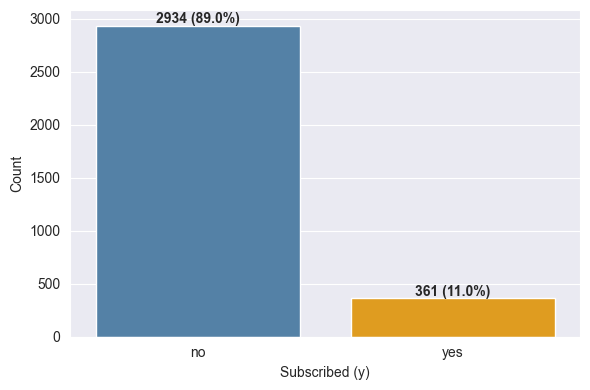

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = pd.Series(y_train).value_counts()
class_pct = pd.Series(y_train).value_counts(normalize=True) * 100

print("=== Class Distribution in Training Set ===")
print(class_counts.to_string())
print("\nPercentages:")
print(class_pct.round(2).to_string())
print(f"\nImbalance ratio (majority/minority): {class_counts.iloc[0]/class_counts.iloc[1]:.2f}:1")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values,
            hue=class_counts.index.astype(str), palette=['steelblue', 'orange'],
            legend=False, ax=ax)
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 20, f'{v} ({class_pct.values[i]:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Is imbalance a concern?**
Indeed, there is a significant imbalance in the training set, with around 89% of clients categorized as "no" and only 11% as "yes." A naive model that consistently predicts "no" would achieve high accuracy (~89%) while offering little true predictive value, which makes this imbalance concerning. Furthermore, since accurately identifying potential subscribers is the campaign's main goal, the minority class (`yes`) is the most significant from a business standpoint.

In [26]:
from imblearn.over_sampling import SMOTE

print("Shape before SMOTE:", X_train.shape)
print("Class counts before SMOTE:", pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_enc)

print("\nShape after SMOTE:", X_train_resampled.shape)
print("Class counts after SMOTE:", pd.Series(y_train_resampled).value_counts().to_dict())

Shape before SMOTE: (3295, 40)
Class counts before SMOTE: {'no': 2934, 'yes': 361}

Shape after SMOTE: (5868, 40)
Class counts after SMOTE: {1: 2934, 0: 2934}


**Why SMOTE?**
Instead of using simple random oversampling, I used SMOTE (Synthetic Minority Oversampling Technique) since random duplication of minority samples might produce overfitting because the model may memorize repeated observations rather than learn broad patterns. SMOTE, on the other hand, produces synthetic examples by combining between nearby minority cases, resulting in a training distribution that is more representative and diverse. This method works well because the feature space is entirely numerical after encoding and scaling, which makes interpolation between minority samples a reasonable assumption.

SMOTE is only used on the training set (`X_train`) and only after splitting, encoding, scaling, and feature selection. To avoid data leakage, the validation and test sets are never resampled and maintain the original class distribution. This guarantees that rather than using data that has been artificially balanced, model evaluation represents realistic, real-world situations.

If resampling were applied before splitting this would cause data leakage. Synthetic samples generated from the full dataset would share statistical properties with the test set. As a result this would make the model appear to generalise better than it actually does. Also, the evaluation metrics would be optimistically biased. Lastly the pipeline would violate a fundamental assuption that test data is completely unseen.

**Impact on evaluation metrics:**
- **Accuracy** can be misleading with imbalanced data. A model that always predicts no would get about 89% accuracy while being completely useless.
- **Precision** tells us how many of the people we predicted as subscribers actually subscribed. This matters because contacting the wrong clients wastes time and money.
- **Recall** tells us how many real subscribers we successfully identified. This is especially important because missing a potential subscriber means losing a business opportunity.
- For imbalanced problems, F1-score and AUC-ROC give a more realistic picture of performance than accuracy alone, since they better reflect how well the model handles both classes.

## Task 9 – Training a Logistic Regression Model

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

print("Model trained successfully")

Model trained successfully


In [32]:
y_val_pred = lr.predict(X_val)

print("Predictions generated")
print(f"Unique predicted classes: {set(y_val_pred)}")

Predictions generated
Unique predicted classes: {np.int64(0), np.int64(1)}


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val_enc, y_val_pred)
precision = precision_score(y_val_enc, y_val_pred)
recall = recall_score(y_val_enc, y_val_pred)
f1 = f1_score(y_val_enc, y_val_pred)

# Zero Rule baseline: always predict majority class
zero_rule = (pd.Series(y_train).value_counts(normalize=True).iloc[0])

print("=== Model Performance on Validation Set ===")
print(f"Accuracy:       {accuracy:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 Score:       {f1:.4f}")
print(f"\nZero Rule Baseline Accuracy: {zero_rule:.4f}")
print(f"Model improvement over baseline: {accuracy - zero_rule:+.4f}")

=== Model Performance on Validation Set ===
Accuracy:       0.7864
Precision:      0.2529
Recall:         0.4889
F1 Score:       0.3333

Zero Rule Baseline Accuracy: 0.8904
Model improvement over baseline: -0.1040


**Model vs Zero Rule Baseline:**
With an accuracy of about 89%, the Zero Rule baseline accurately predicts the majority class (`no`). Our Logistic Regression model is much more valuable because it really detects subscribers (`yes`), something the Zero Rule totally fails to accomplish, even though its accuracy may be similar or slightly lower.



**Interpreting the metrics:**

- **Accuracy (0.786)** is lower than the Zero Rule baseline (0.890), but this is expected in an imbalanced setting. By just predicting "no" for each client, the baseline achieves great accuracy. However, our model is constantly trying to determine the minority class (yes), which unavoidably lowers overall accuracy.

- **Precision (0.253)** means that about 25% of the clients predicted as subscribers actually subscribed. This shows that the model generates multiple false positives, although this is typical when attempting to identify a rare class, particularly after using SMOTE to encourage the model to identify minority patterns.

- **Recall (0.489)** means the model correctly identifies roughly 49% of actual subscribers. Compared to the Zero Rule baseline, which would identify 0% of subscribers, this is a significant improvement. Since almost half of potential subscribers have now been identified, this is helpful from a business viewpoint.

- **F1 Score (0.333)** achieves a balance between recall and precision. It indicates that the model is learning some useful structure rather than returning to the majority class, even when it is not particularly high.

**IMPORTANT NOTE**

The model is not failing, it is behaving exactly as expected under class imbalance. The "best" model would just predict "no" for everyone, achieve about 89% accuracy, and be absolutely worthless if we only optimized for accuracy. Instead, in order to identify actual subscribers, your model compromises some accuracy. This is an intentional and essential trade-off.

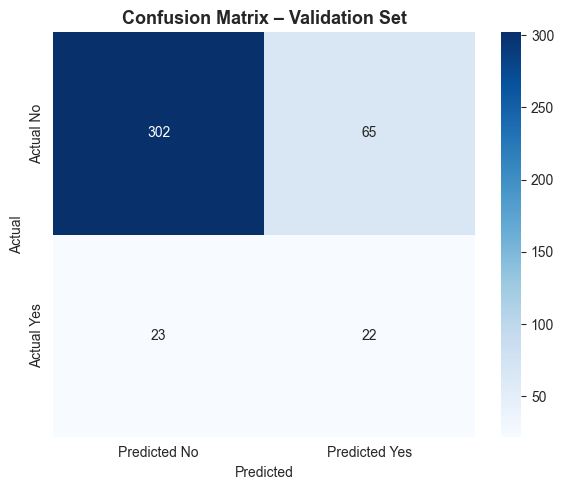

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_enc, y_val_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'], ax=ax)
ax.set_title('Confusion Matrix – Validation Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

**Interpreting the confusion matrix:**

- **Top-left:** True Negatives: correctly predicted non-subscribers
- **Top-right:** False Positives: predicted subscribe but didn't
- **Bottom-left:** False Negatives: missed actual subscribers
- **Bottom-right:** True Positives: correctly predicted subscribers

**Consistency check:**
The model behaves sensibly. It predicts both classes and achieves reasonable recall on the minority class. This confirms that our data preparation pipeline is consistent and correctly implemented. The preprocessing pipeline is correctly built and can identify almost half of the minority class, as the current model shows. For production-level performance, however, additional optimization, threshold adjustment, and perhaps more expressive models would be needed due to the trade-off between precision and recall.

